# Imports

In [1]:
import pandas as pd
import numpy as np

from matplotlib import pyplot as plt
from matplotlib.pyplot import text

from data_loader import get_ensembles, collect_divbo_data, get_autosklearn, load_diversity, \
    load_runtimes, load_multiple_data
from filepaths import AUTO_CEN_DP, AUTO_CEN, AUTOSKLEARN_DIV, AUTOSKLEARN, DIV_BO, AUTO_CEN_DP_MULTI
from helper import get_mean, mean_sd_tables, get_sd

small_data_ids = ["1005", "40981", "1494", "23", "40984"]
high_dimensional_ids = ["41145", "40926", "554", "40996", "41163"]
class_imbalance_ids = ["40900", "30", "1461", "40668"]
multiple_ids = ["1067", "40983", "40498", "1486", "4134", "40978"]

def sort_by_characteristic(df: pd.DataFrame) -> pd.DataFrame:
    """
    Sort the given dataframe by the datasets.
    
    :param df: The dataframe to be sorted.
    :return: The sorted dataframe.
    """
    sorter = [*small_data_ids, *high_dimensional_ids, *class_imbalance_ids, *multiple_ids]
    sorter = list(map(str, sorter))
    df["data_id"] = df["data_id"].astype("category")
    df["data_id"] = df["data_id"].cat.set_categories(sorter, ordered=True)
    df = df.sort_values("data_id")
    return df

# I. Create Performance Tables (Table I and Table II)

In [2]:

def _create_dc_table(data_ids:list, df_autocen_dp: pd.DataFrame, df_baselines: list, baseline_names: list, metric: str) -> pd.DataFrame:
    """
    Summarize evaluation results.
    
    :param data_ids: The IDs of the dataset to be shown in the table
    :param df_autocen_dp: The evaluation results of Auto-CEn+DP
    :param df_baselines: The evaluation results of the baselines
    :param baseline_names: The names of the baselines
    :param metric: The metric to evaluate
    """
    # 1. Select rows in df where data_id in data_ids    
    df_autocen_dp = df_autocen_dp.loc[df_autocen_dp['data_id'].isin(data_ids)]
    
    # 2. Per df in df_compare: Select rows where data_in in data_ids
    df_baselines = [df.loc[df['data_id'].isin(data_ids)] for df in df_baselines]
    
    # 3. Compute results for Auto-CEn+DP
    mean_autocen_dp = get_mean(df_autocen_dp, metric).dropna().rename(columns={metric: "Auto-CEn+DP"}).set_index(["data_id"]).T
    sd_autocen_dp = get_sd(df_autocen_dp, metric).dropna().rename(columns={metric: "Auto-CEn+DP"}).set_index(["data_id"]).T
    
    # 4. Build results for baselines
    for i, df_baseline in enumerate(df_baselines):
        # Compute the values for the baseline and add them to the mean table
        mean_baseline = get_mean(df_baseline, metric).set_index(["data_id"]).T
        mean_autocen_dp.loc[baseline_names[i]] = mean_baseline.loc[metric]

        # Compute the values for the baseline and add them to the sd table
        sd_baseline = get_sd(df_baseline, metric).dropna().set_index(["data_id"]).T
        sd_autocen_dp.loc[baseline_names[i]] = sd_baseline.loc[metric]
        
    # 5. Add the Average column and do some formatting
    mean_table = mean_autocen_dp.rename(columns={"data_id": "Dataset"})
    mean_table["Avg."] = mean_table.mean(axis=1)
    mean_table = mean_table.round(2)
    sd_table = sd_autocen_dp.round(2)
    sd_table["Avg."] = None
    
    # 6. Merge mean and standard deviation tables
    merged_table = mean_sd_tables(mean_table, sd_table, 2) 
        
    return merged_table

def create_performance_tables(metric: str):
    """
    Create and print the tables used in the paper in Section IV.B
    
    :param metric: The metric to evaluate.
    """
    # 1. Load Auto-CEn+DP
    df_autocen_dp = get_ensembles(AUTO_CEN_DP, metric, only_fusion=True)
    df_autocen_dp = sort_by_characteristic(df_autocen_dp)
    
    # 2. Load Auto-CEn+DP for Multiple Data Characteristics
    df_multi_sd, df_multi_hd, df_multi_ci, df_multi = load_multiple_data(AUTO_CEN_DP_MULTI, metric)
    df_multi =  sort_by_characteristic(df_multi)

    # 3. Load Auto-CEn
    df_auto_cen = get_ensembles(AUTO_CEN, metric, only_fusion=True)
    # 4. Load Auto-Sklearn
    df_as = get_autosklearn(AUTOSKLEARN)[["data_id", metric, "seed"]]
    # 5. Load DivBO
    df_divbo = collect_divbo_data(DIV_BO)

    df_baselines = [df_auto_cen, df_as, df_divbo]
    baseline_names = ["Auto-CEn", "autosklearn", "DivBO"]


    # 1. Create SD Table
    df_sd = _create_dc_table(small_data_ids,df_autocen_dp, df_baselines, baseline_names, metric)
    print("--------- SD ---------")
    print(df_sd)

    # 2. Create HD Table
    df_hd = _create_dc_table(high_dimensional_ids, df_autocen_dp, df_baselines, baseline_names, metric)
    print("--------- HD ---------")
    print(df_hd)
    
    # 3. Create CI Table
    df_ci = _create_dc_table(class_imbalance_ids,df_autocen_dp, df_baselines, baseline_names, metric)
    print("--------- CI ---------")
    print(df_ci)
    
    # 4. Create Shared Table
    df_large = _create_dc_table(multiple_ids,df_multi,[df_multi_sd, df_multi_hd, df_multi_ci] + df_baselines, ["Auto-CEn+DP (SD)", "Auto-CEn+DP (HD)", "Auto-CEn+DP (CI)"] +baseline_names, metric)
    print("-------- MULTI --------")
    print(df_large)

create_performance_tables("balanced_accuracy")


--------- SD ---------
                   1005       40981        1494          23       40984  \
Auto-CEn+DP  85.88±7.08  85.56±2.77   87.1±2.11  56.34±1.83  95.11±0.85   
Auto-CEn      84.5±7.28   84.5±2.08  86.11±1.48  55.18±1.96   94.2±0.96   
autosklearn  81.31±7.16  84.53±1.57  84.85±1.85  54.65±2.43  94.11±0.94   
DivBO        77.98±5.51  82.25±1.79  82.34±2.24  53.04±4.03   94.5±1.08   

                   Avg.  
Auto-CEn+DP   82.0±None  
Auto-CEn      80.9±None  
autosklearn  79.89±None  
DivBO        78.02±None  
--------- HD ---------
                  41145       40926         554       40996       41163  \
Auto-CEn+DP  80.31±1.98  45.67±0.54  97.58±0.05  87.79±0.35  98.01±0.42   
Auto-CEn     77.26±1.64   40.5±0.68  96.27±0.15  87.18±0.13   98.0±0.25   
autosklearn  78.73±1.47   44.77±1.9  95.93±2.26  86.49±2.21  97.95±0.55   
DivBO        76.66±1.29   45.14±3.9   94.55±3.6  87.63±0.43   94.8±4.05   

                   Avg.  
Auto-CEn+DP  81.87±None  
Auto-CEn     79.84±N

# 2. Create Diversity Table (Table III)

In [3]:
def diversity_summary_table(metric: str):
    """
    Create and print the tables used in the paper in Section IV.C
    
    :param metric: The metric to evaluate.
    """
    # 1. Load Auto-CEn+DP
    df_auto_cen_dp = load_diversity(AUTO_CEN_DP, [metric])
    df_auto_cen_dp = sort_by_characteristic(df_auto_cen_dp)
    
    # 2. Load Auto-CEn+DP for data with multiple data characteristics
    _, _, _, df_multi = load_multiple_data(AUTO_CEN_DP_MULTI, metric, data_type="diversity")
    df_multi =  sort_by_characteristic(df_multi)
    df_auto_cen_dp = pd.concat([df_auto_cen_dp, df_multi], ignore_index=True)

    # 4. Load Auto-CEn
    df_auto_cen = load_diversity(AUTO_CEN,[metric])
    df_auto_cen = sort_by_characteristic(df_auto_cen)

    # 4. Load Auto-sklearn
    df_as = load_diversity(AUTOSKLEARN_DIV, [metric], True)
    df_as["data_id"] = df_as["data_id"].astype(int).astype(str)
    df_as = sort_by_characteristic(df_as)

    # 5. DivBO
    df_divbo = collect_divbo_data(DIV_BO)
    df_divbo = sort_by_characteristic(df_divbo)

    column_first = []
        
    column_first.append(metric)

    baselines = ["Auto-CEn+DP", "Auto-CEn", "auto-sklearn", "DivBO"]
    dcs = ["SD", "HD", "CI", "Multi", "Overall"]
    index_second = []
    index_first = []
    for d in dcs:
        for b in baselines:
            index_first.append(d)
        index_second += baselines
    d_ids = [small_data_ids, high_dimensional_ids, class_imbalance_ids, multiple_ids]
    index_dfs = [df_auto_cen_dp, df_auto_cen, df_as, df_divbo]

    graph_data = []
    rows = []
    sd_rows = []
    for j in range(len(dcs)):
        dfs = index_dfs
        if dcs[j] != "Overall":
            dfs = [df[df["data_id"].isin(d_ids[j])] for df in index_dfs]
        for i in range(len(baselines)):
            row = []
            graph_row = [dcs[j], baselines[i]]
            sds = []
            mean = get_mean(dfs[i], metric, False)
            sd = mean[metric].std()
            sds.append(sd)
            row.append(mean[metric].mean())
            graph_row.append(mean[metric].mean())

            rows.append(row)
            sd_rows.append(sds)
            graph_data.append(graph_row + sds)

    df = pd.DataFrame(data=rows, index=[index_first, index_second], columns=column_first)

    df_sd = pd.DataFrame(data=sd_rows, index=[index_first, index_second], columns=column_first)

    merged_table = mean_sd_tables(df, df_sd, 2) 
    print(merged_table)
        
diversity_summary_table("doublefault")

                     doublefault
SD      Auto-CEn+DP    0.14±0.11
        Auto-CEn       0.13±0.12
        auto-sklearn   0.14±0.12
        DivBO           0.16±0.1
HD      Auto-CEn+DP    0.14±0.17
        Auto-CEn       0.17±0.21
        auto-sklearn    0.19±0.2
        DivBO          0.22±0.17
CI      Auto-CEn+DP    0.05±0.05
        Auto-CEn       0.05±0.05
        auto-sklearn   0.08±0.06
        DivBO          0.05±0.05
Multi   Auto-CEn+DP     0.1±0.11
        Auto-CEn       0.09±0.09
        auto-sklearn   0.13±0.14
        DivBO           0.11±0.1
Overall Auto-CEn+DP    0.11±0.12
        Auto-CEn       0.11±0.13
        auto-sklearn   0.14±0.13
        DivBO          0.14±0.12


# III. Plot Runtime (Figure 4)

Median Runtime Auto-CEn+DP: 1182.92
Median Runtime Auto-CEn: 959.97
Median Runtime Auto-sklearn: 1594.8
Median Runtime DivBO: 3778.12


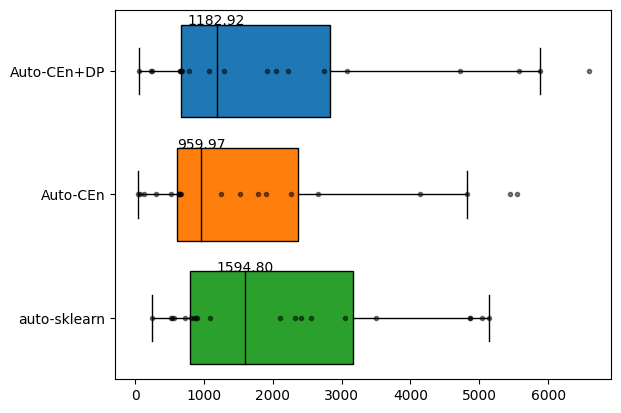

In [4]:
def _plot_box(ax, df:pd.DataFrame, color:str, i:int, label: str, metric: str):
    """
    Plot a box for a boxplot.
    """
    ix = 1 - (i * 0.2)
    box = ax.boxplot(df[metric].dropna(), vert=False, positions=[ix], labels=[label],
                     showfliers=False,
                     patch_artist=True)
    box["boxes"][0].set_facecolor(color)
    box['medians'][0].set_color("black")
    # get position data for median line
    x, y = box['medians'][0].get_xydata()[1]  # top of median line
    # overlay median value
    text(x, y, '%.2f' % x, horizontalalignment='center')  # draw above, centered
    y = np.random.normal(ix, 0.0, size=len(df))
    ax.plot(df[metric], y, "k.", alpha=0.5)

def runtime_compare():
    """
    Create and show the figure in Section IV.D.
    """
    # 1. Load Auto-CEn+DP
    df_auto_cen_dp = load_runtimes(AUTO_CEN_DP)
    _, _, _, df_multi = load_multiple_data(AUTO_CEN_DP_MULTI, "model optimization", data_type="runtime")
    df_auto_cen_dp = pd.concat([df_auto_cen_dp, df_multi], ignore_index=True)
    df_auto_cen_dp["runtime"] = df_auto_cen_dp["model optimization"]
    df_auto_cen_dp = get_mean(df_auto_cen_dp, "runtime", False)
    df_auto_cen_dp = sort_by_characteristic(df_auto_cen_dp)

    # 2. Load Auto-CEn
    df_auto_cen = load_runtimes(AUTO_CEN)
    df_auto_cen["runtime"] = df_auto_cen["model optimization"]
    df_auto_cen = get_mean(df_auto_cen, "runtime", False)

    # 3. Load Auto-sklearn
    df_as = get_autosklearn(AUTOSKLEARN)
    df_as = get_mean(df_as, "runtime", False)

    # 4. Load DivBO
    df_divbo = collect_divbo_data(DIV_BO)
    df_divbo = get_mean(df_divbo, "runtime", False)
    
    print(f"Median Runtime Auto-CEn+DP: {round(df_auto_cen_dp['runtime'].median(),2)}")
    print(f"Median Runtime Auto-CEn: {round(df_auto_cen['runtime'].median(),2)}")
    print(f"Median Runtime Auto-sklearn: {round(df_as['runtime'].median(),2)}")
    print(f"Median Runtime DivBO: {round(df_divbo['runtime'].median(),2)}")


    fig, ax = plt.subplots(1)
    _plot_box(ax, df_auto_cen_dp, "C0", 0, "Auto-CEn+DP", "runtime")
    _plot_box(ax, df_auto_cen, "C1", 1, "Auto-CEn", "runtime")
    _plot_box(ax, df_as, "C2", 2, "auto-sklearn", "runtime")

    ax.set_ylim(0.5, 1.1)
    plt.show()
    
runtime_compare()